In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

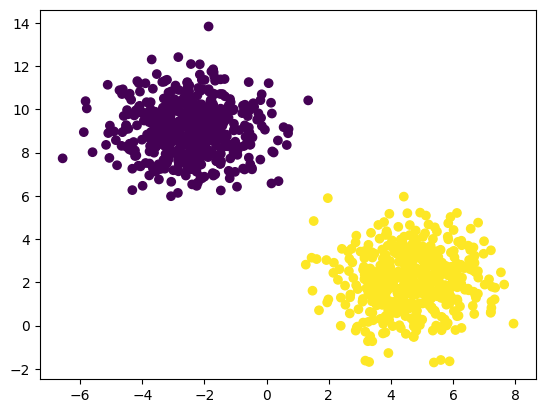

In [281]:
df = make_blobs(n_samples=1000, n_features=2, centers=2 , cluster_std=1.25, random_state=42)

X = df[0]
y = df[1]
plt.scatter(X[:,0], X[:,1], c=y)

In [282]:
p = int(len(X)*0.75)
X_train, y_train = X[0:p], y[0:p]
X_test, y_test = X[p:], y[p:]

print(X_train.shape, y_train.shape, X_test.shape , y_test.shape)

(750, 2) (750,) (250, 2) (250,)


In [283]:
def sigmoid(logit):
    return 1/(1+np.exp(-(logit)))

In [284]:
def classification_report(y, y_pred):

    y = np.asarray(y).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    tp = np.sum((y == 1) & (y_pred == 1))
    tn = np.sum((y == 0) & (y_pred == 0))
    fp = np.sum((y == 0) & (y_pred == 1))
    fn = np.sum((y == 1) & (y_pred == 0))

    acc = (tp + tn) / (tp + tn + fp + fn)

    precision = (
        tp / (tp + fp)
        if (tp + fp) != 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) != 0
        else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) != 0
        else 0
    )

    return (
        f"acc: {acc:.4f} | "
        f"precision: {precision:.4f} | "
        f"recall: {recall:.4f} | "
        f"f1: {f1:.4f}"
    )

In [285]:
class LogisticRegression():
    def __init__(self, lr):
        self.w = None
        self.b = None
        self.lr = lr
        self.costs = []
        self.acc = []
        
    def predict(self, X):
        return sigmoid((X @ self.w) + self.b)
    
    def compute_cost(self, y, y_pred):
        n = len(y)
        return - np.sum((y * np.log(y_pred)) + ((1-y) * np.log(1-y_pred))) / n
    
    def update(self, X, y, y_pred):
        n = len(y)
        self.dw = (X.T @ (y_pred - y)) / n
        self.db = np.sum(y_pred - y)/n
        
    def fit(self, X_train, y_train, epochs):
        self.w = np.zeros(X_train.shape[1])
        self.b = 0.0
        for i in range(epochs):
            y_pred = self.predict(X_train)
            cost = self.compute_cost(y_train, y_pred)
            self.costs.append(cost)
            self.update(X_train, y_train, y_pred)
            
            self.w -= self.lr * self.dw
            self.b -= self.lr * self.db
            
            y_hat = (y_pred >= 0.5).astype(int)
            
            if i % 50 == 0:
                print(f"classification_report: {classification_report(y_train, y_hat)}    |    cost: {self.compute_cost(y_train, y_pred)}")
        

In [286]:
mean = X_train.mean()
std = X_train.std()

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

In [287]:
model = LogisticRegression(lr=0.005)

model.fit(
    X_train_scaled,
    y_train,
    epochs=10000
)

classification_report: acc: 0.4933 | precision: 0.4933 | recall: 1.0000 | f1: 0.6607    |    cost: 0.6931471805599454
classification_report: acc: 0.9667 | precision: 1.0000 | recall: 0.9324 | f1: 0.9650    |    cost: 0.6193139176135054
classification_report: acc: 0.9680 | precision: 1.0000 | recall: 0.9351 | f1: 0.9665    |    cost: 0.5606219262113541
classification_report: acc: 0.9733 | precision: 1.0000 | recall: 0.9459 | f1: 0.9722    |    cost: 0.513162439873868
classification_report: acc: 0.9813 | precision: 1.0000 | recall: 0.9622 | f1: 0.9807    |    cost: 0.4740597996357722
classification_report: acc: 0.9813 | precision: 1.0000 | recall: 0.9622 | f1: 0.9807    |    cost: 0.4412517464311186
classification_report: acc: 0.9827 | precision: 1.0000 | recall: 0.9649 | f1: 0.9821    |    cost: 0.41326638492531975
classification_report: acc: 0.9827 | precision: 1.0000 | recall: 0.9649 | f1: 0.9821    |    cost: 0.38904583854468017
classification_report: acc: 0.9840 | precision: 1.0000 

In [288]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)
y_hat_test = (y_pred_test >= 0.5).astype(int)

print(classification_report(y_test, y_hat_test))

acc: 1.0000 | precision: 1.0000 | recall: 1.0000 | f1: 1.0000


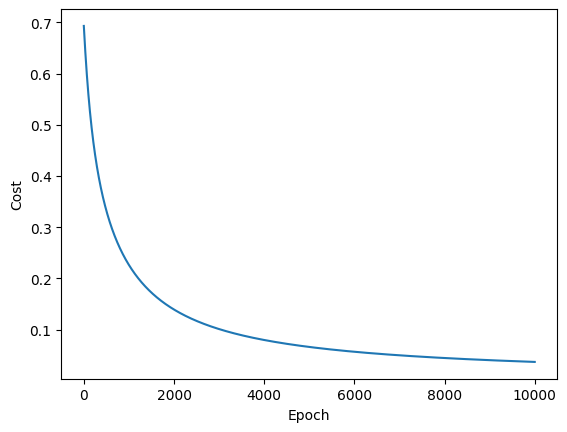

In [289]:
plt.plot(model.costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

In [290]:
model.b

1.8869449621512233

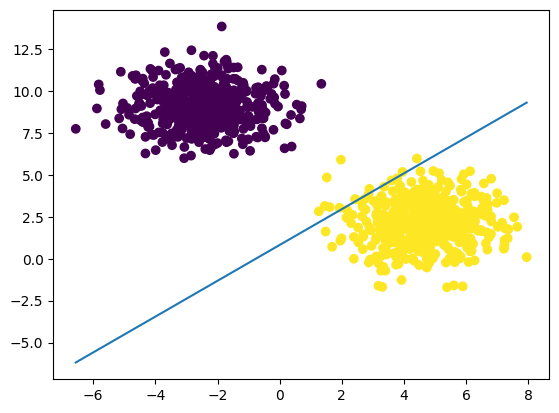

In [291]:
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

x2 = -(model.w[0] * x1 + model.b) / model.w[1]

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot(x1, x2)
plt.show()